## API Setup

In [28]:
#!pip install matplotlib
#!pip install sklearn
#!pip install shap
#!pip install xgboost

# Underwriting Model Study Case
The workflow is divided into the following stages:

1. Import libraries
2. Load raw exposure and claim data
3. Preprocess and validate the data
4. Map KCD-9 codes and analyze claim distribution by KCD chapter
5. Build a 5-year disease-history cohort
6. Create 3-, 4-, and 5-year follow-up cohorts
7. Build a simple logistic-regression benchmark model
8. Compare AUC, odds ratio, predicted risks, and model-based relative risk
9. Export the model results to Excel

The original modeling logic is preserved as much as possible. Korean code comments have been translated into English.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import re

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

## 1. Raw Data Loader

The raw exposure and claim datasets are stored as pickle files.  
`Read_pickle_data()` loads both datasets and returns them as a dictionary.

In [30]:
def Read_pickle_data(exposure_file_nm, claim_file_nm):
    """
    By reading pickle raw data, raw datasets can be loaded efficiently.
    """

    exposure_data = pd.read_pickle(exposure_file_nm)
    claim_data = pd.read_pickle(claim_file_nm)

    return {
        'Exposure_data': exposure_data,
        'Claim_data': claim_data
    }

## 2. Input File Configuration

Define the filenames used throughout the analysis.

In [31]:
exposure_file_nm = 'Raw_exposure_data.pickle'
claim_file_nm = 'Raw_claim_data.pickle'

## 3. Preprocessing Class

This class performs the basic preprocessing steps before cohort construction and modeling.

Main tasks:

- Normalize sex codes
- Convert inpatient start date into `Claim_Date`
- Check consistency between exposure and claim insured IDs
- Check available exposure duration
- Merge claim records with the KCD-9 master table

In [32]:
class Preprocessing:

    def __init__(self, exposure_df, claim_df):

        self.__exposure_data = exposure_df
        self.__claim_data = claim_df

        """
        Normalize selected columns:
            Sex code: 1 = Male, 2 = Female
        """

        sex_code_chck = (
            self.__claim_data['Sex']
            .astype('string')
            .str.contains(r"[가-힣A-Za-z]", na=False)
        )

        if sex_code_chck.any() == True:
            self.__claim_data['Sex'] = (
                self.__claim_data['Sex']
                .str.replace('남', '1', regex=False)
            )
            self.__claim_data['Sex'] = (
                self.__claim_data['Sex']
                .str.replace('여', '2', regex=False)
            )

        self.__claim_data['Claim_Date'] = pd.to_datetime(
            self.__claim_data['In-patient_st_date']
            .astype('Int64')
            .astype('string'),
            format='%Y%m%d',
            errors='coerce'
        )

    def get_exposure_data(self):
        return self.__exposure_data.copy()

    def get_claim_data(self):
        return self.__claim_data.copy()

    def Domain_check(self):
        """
        Pre-processing Level 1: Domain Check Process

        Check exposure and claim insured IDs.
        Claim insured IDs that do not exist in exposure data are treated as invalid.
        """

        exposure_id = list(self.__exposure_data.Insured_ID.unique())
        claim_id = list(self.__claim_data.Insured_ID.unique())

        valid_claim_id = list(
            set(claim_id) - (set(claim_id) - set(exposure_id))
        )

        group_exposure = (
            self.__exposure_data
            .groupby('Insured_ID')
            .sum('Exposure')
        )

        over_eight_exp = group_exposure.loc[group_exposure['Exposure'] >= 8]
        over_nine_exp = group_exposure.loc[group_exposure['Exposure'] >= 9]
        over_ten_exp = group_exposure.loc[group_exposure['Exposure'] >= 10]

        insured_id_cnt = self.__exposure_data['Insured_ID'].value_counts()
        kcd_cnt = self.__claim_data['KCD'].value_counts()

        print(f'insured_id_cnt : {insured_id_cnt}')
        print(f'kcd_cnt : {kcd_cnt}')

        # Check the number of insureds by available exposure period
        # to help determine the statistical observation period.
        print(f'count of insured ids at least 8year exposure : {over_eight_exp.shape[0]}')
        print(f'count of insured ids at least 9year exposure : {over_nine_exp.shape[0]}')
        print(f'count of insured ids at least 10year exposure : {over_ten_exp.shape[0]}')

        # Count all insured IDs in exposure data.
        print(f'check exposure id cnt: {len(exposure_id)}')

        # Count all insured IDs in claim data.
        print(f'check claim id cnt: {len(claim_id)}')

        # Count claim insured IDs that also exist in exposure data.
        print(f'check valid claim id cnt: {len(valid_claim_id)}')

    def KCD_code_chg(self):
        """
        Add detailed definitions for each KCD code.
        KCD classification has some differences from ICD.
        """

        self.KCD_data = pd.read_excel(
            'KCD-9_mst.xlsx',
            sheet_name='상병분류기호(완전코드)',  # KCD code master
            usecols='B:D',
            header=10,
            engine='openpyxl'
        )

        # Rename the disease-code column to KCD.
        self.KCD_data.rename(columns={'상병기호': 'KCD'}, inplace=True)

        self.kcd_concat_claim = pd.merge(
            self.__claim_data,
            self.KCD_data,
            on='KCD',
            how='inner'
        )

        return self.kcd_concat_claim

## 4. Load and Preprocess Raw Data

Run the preprocessing workflow and perform the domain checks before KCD analysis.

In [33]:
raw_data = Read_pickle_data(
    exposure_file_nm=exposure_file_nm,
    claim_file_nm=claim_file_nm
)

exposure_data = raw_data['Exposure_data']
claim_data = raw_data['Claim_data']

prepare = Preprocessing(
    exposure_df=exposure_data,
    claim_df=claim_data
)

processed_exposure = prepare.get_exposure_data()
processed_claim = prepare.get_claim_data()

print(prepare.Domain_check.__doc__)
prepare.Domain_check()

print(prepare.KCD_code_chg.__doc__)
KCD_claim_data = prepare.KCD_code_chg()


Pre-processing Level 1: Domain Check Process

Check exposure and claim insured IDs.
Claim insured IDs that do not exist in exposure data are treated as invalid.

insured_id_cnt : Insured_ID
1105043/GobqquRak2NCCvDfIbqSg==    32
1105043+tvGSFg3mQCN1CxgAswfnw==    32
1105043+WbfpMOpAL/1pb0gbgS8eQ==    32
11050433pK5rxcunSBqIq6y+1alIA==    32
11050435cK45REoj9OzyDC7QZqNdQ==    32
                                   ..
7805046pnNRA4QGD21r8iUK4NL2YQ==     1
5705046fmf8tSygwacDvrF3wuwUPw==     1
78050421s9wDTAzD2ivcDOIYSkT8g==     1
00050432TCIBAgS4jGtFsWIG5N6Qg==     1
79050417kZD5RzUkQEExwNbdhAUHA==     1
Name: count, Length: 21884, dtype: int64
kcd_cnt : KCD
J00      20365
M62      20098
R69      12463
M545      9539
R52       7061
         ...  
R270         1
W19          1
H511         1
M5439        1
S9348        1
Name: count, Length: 3720, dtype: int64
count of insured ids at least 8year exposure : 11910
count of insured ids at least 9year exposure : 10991
count of insured ids at l

## 5. KCD Chapter-Level Claim Analysis

`Data_Analyze` classifies claims into KCD-9 chapters using a chapter-range reference file.

It then:

- Cleans the KCD code
- Extracts the first three characters
- Maps each claim to a KCD chapter
- Counts claims by chapter
- Calculates the claim weight of each chapter
- Plots the chapter-level claim counts  
  

### ICD vs. KCD

- **ICD**: International disease classification system maintained by the WHO.
- **KCD**: Korean adaptation of ICD, reflecting Korea-specific medical, statistical, and insurance needs.
- The overall classification structure is similar, but some detailed codes and subcategories may differ.
- Therefore, this analysis uses **KCD-9** as the reference classification system for Korean claim data.

In [34]:
class Data_Analyze(Preprocessing):

    """
    Analyze exposure and claim data by KCD classification
    and plot the distribution for exploratory analysis.
    """

    def __init__(
        self,
        kcd_concat_claim: pd.DataFrame,
        chapter_file: str = 'KCD9_대분류별_분류요건.csv'
    ) -> None:

        """
        Create classified claim data using KCD chapter definitions.
        """

        self.kcd_concat_claim = kcd_concat_claim.copy()

        # KCD-9 chapter information
        self.chapter_inf = pd.read_csv(chapter_file, header=0)

        self.KCD_lvl3 = tuple(
            zip(
                self.chapter_inf['시작코드'],  # Start of KCD range
                self.chapter_inf['종료코드'],  # End of KCD range
                self.chapter_inf['대분류명']   # KCD chapter name
            )
        )

    def chapter_counting(self) -> pd.DataFrame:

        self.kcd_concat_claim['KCD_clean'] = (
            self.kcd_concat_claim['KCD']
            .astype('string')
            .str.strip()
            .str.upper()
            .str.replace('.', '', regex=False)
        )

        # Use the first three characters to classify each KCD chapter.
        self.kcd_concat_claim['KCD_lvl3'] = self.kcd_concat_claim['KCD_clean'].str[:3]

        conditions: list[pd.Series] = []
        chapter_labels: list[str] = []

        for start_code, end_code, chapter_name in self.KCD_lvl3:
            condition = self.kcd_concat_claim['KCD_lvl3'].between(
                start_code,
                end_code,
                inclusive='both'
            )
            conditions.append(condition)
            chapter_labels.append(f'{chapter_name}({start_code}-{end_code})')

        self.kcd_concat_claim['KCD_Chapter'] = np.select(
            conditions,
            chapter_labels,
            default='Unclassified'
        )

        chapter_order = chapter_labels + ['Unclassified']

        chapter_count = (
            self.kcd_concat_claim['KCD_Chapter']
            .value_counts()
            .reindex(chapter_order, fill_value=0)
            .rename_axis('KCD_Chapter')
            .reset_index(name='Claim_Count')
        )

        chapter_count['Claim_Weight'] = (
            chapter_count['Claim_Count']
            / chapter_count['Claim_Count'].sum()
        )

        return self.kcd_concat_claim, chapter_count

    @staticmethod
    def plot_chapter_count(chapter_count: pd.DataFrame) -> None:

        # Use a Korean-compatible font for KCD chapter labels.
        mpl.rcParams["font.family"] = "Malgun Gothic"
        mpl.rcParams["axes.unicode_minus"] = False

        plot_data = chapter_count.loc[chapter_count['Claim_Count'] > 0].copy()

        plt.figure(figsize=(15, 8))
        bars = plt.bar(plot_data['KCD_Chapter'], plot_data['Claim_Count'])

        plt.title('Number of Claim Records by KCD-9 Chapter')
        plt.xlabel('KCD-9 Chapter')
        plt.ylabel('Claim Record Count')
        plt.xticks(rotation=60, ha='right')

        for bar, count in zip(bars, plot_data['Claim_Count']):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f'{count:,}',
                ha='center',
                va='bottom'
            )

        plt.tight_layout()
        plt.show()

## 6. Run the KCD Chapter Analysis

This step creates `KCD_lvl3`, which is later used to define respiratory history and future cardiovascular outcomes.

,KCD_Chapter,Claim_Count,Claim_Weight
0,Certain infectious and parasitic diseases(A00-...,39094,0.056033
1,Neoplasms(C00-D48),24446,0.035038
2,Diseases of the blood and blood-forming organs...,1669,0.002392
3,"Endocrine, nutritional and metabolic diseases(...",50015,0.071686
4,Mental and behavioural disorders(F00-F99),1939,0.002779
5,Diseases of the nervous system(G00-G99),8148,0.011678
6,Diseases of the eye and adnexa(H00-H59),10649,0.015263
7,Diseases of the ear and mastoid process(H60-H95),4608,0.006605
8,Diseases of the circulatory system(I00-I99),21127,0.030281
9,Diseases of the respiratory system(J00-J99),215104,0.308305


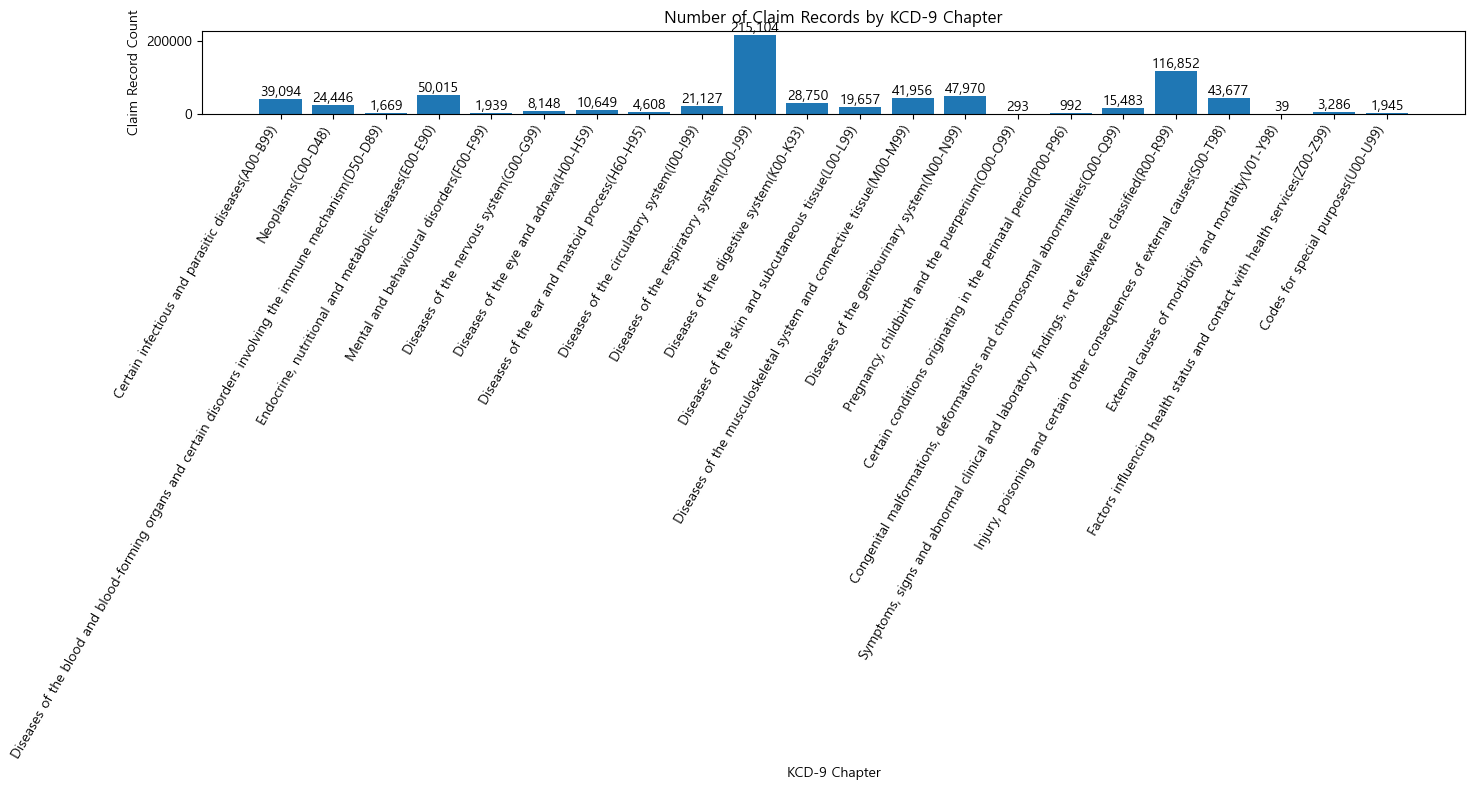

In [35]:
analysis = Data_Analyze(kcd_concat_claim=KCD_claim_data)
chapter_result = analysis.chapter_counting()

kcd_claim_with_chapter = chapter_result[0]
chapter_count = chapter_result[1]

display(chapter_count)
analysis.plot_chapter_count(chapter_count)

## 7. Cohort Construction

The historical disease window is fixed at **5 years**.

After the 5-year history period, the model compares future follow-up periods of:

- 3 years
- 4 years
- 5 years

Only insureds with enough exposure to cover the full follow-up period are retained.

`make_respiratory_history()` creates a binary indicator:

- `1`: At least one respiratory KCD claim (`J00-J99`) during the 5-year history period
- `0`: No respiratory claim during the 5-year history period

In [36]:
class Cohort_Analyze:

    """
    The cohort period for past disease history is fixed at 5 years.
    The future follow-up period is compared across 3, 4, and 5 years.
    """

    def __init__(
        self,
        exposure_df: pd.DataFrame,
        claim_df: pd.DataFrame,
        history_years: int = 5
    ) -> None:

        self.exposure_data = exposure_df.copy()
        self.claim_data = claim_df.copy()
        self.history_years = history_years

        print('Cohort Initialize Complete!')

    def make_cohort(
        self,
        index_date: pd.Timestamp,
        followup_years: int
    ) -> dict:

        index_date = pd.Timestamp(index_date)

        history_start_date = index_date - pd.DateOffset(years=self.history_years)
        history_end_date = index_date - pd.Timedelta(days=1)

        followup_start_date = index_date
        followup_end_date = (
            index_date
            + pd.DateOffset(years=followup_years)
            - pd.Timedelta(days=1)
        )

        # Claims observed during the 5-year historical disease period.
        history_claim = self.claim_data.loc[
            self.claim_data['Claim_Date'].between(
                history_start_date,
                history_end_date,
                inclusive='both'
            )
        ].copy()

        # Claims observed during the future follow-up period.
        followup_claim = self.claim_data.loc[
            self.claim_data['Claim_Date'].between(
                followup_start_date,
                followup_end_date,
                inclusive='both'
            )
        ].copy()

        # Exposure observed during the future follow-up period.
        followup_exposure = self.exposure_data.loc[
            self.exposure_data['CY'].between(
                followup_start_date.year,
                followup_end_date.year,
                inclusive='both'
            )
        ].copy()

        insured_exposure = (
            followup_exposure
            .groupby('Insured_ID', as_index=False)
            .agg(Total_Exposure=('Exposure', 'sum'))
        )

        valid_insured = insured_exposure.loc[
            insured_exposure['Total_Exposure'] >= followup_years,
            'Insured_ID'
        ]

        # Keep only insureds who satisfy the required observation period.
        history_claim = history_claim.loc[
            history_claim['Insured_ID'].isin(valid_insured)
        ].copy()

        followup_claim = followup_claim.loc[
            followup_claim['Insured_ID'].isin(valid_insured)
        ].copy()

        followup_exposure = followup_exposure.loc[
            followup_exposure['Insured_ID'].isin(valid_insured)
        ].copy()

        # Display cohort construction results.
        print(
            f"\nHistory period : "
            f"{history_start_date.date()} ~ {history_end_date.date()}"
        )
        print(
            f"Follow-up period : "
            f"{followup_start_date.date()} ~ {followup_end_date.date()}"
        )
        print(f"Follow-up years : {followup_years}")
        print(f"Eligible insured : {valid_insured.nunique():,}")

        return {
            'followup_exposure': followup_exposure,
            'history_claim': history_claim,
            'followup_claim': followup_claim
        }

    def make_respiratory_history(
        self,
        history_claim: pd.DataFrame,
        exposure_df: pd.DataFrame
    ) -> pd.DataFrame:

        claim = history_claim.copy()

        claim['Respiratory_History'] = (
            claim['KCD_lvl3']
            .between('J00', 'J99', inclusive='both')
            .astype(int)
        )

        respiratory_history = (
            claim
            .groupby('Insured_ID')['Respiratory_History']
            .max()
            .reset_index()
        )

        insured = exposure_df[['Insured_ID']].drop_duplicates()

        respiratory_history = insured.merge(
            respiratory_history,
            on='Insured_ID',
            how='left'
        )

        respiratory_history['Respiratory_History'] = (
            respiratory_history['Respiratory_History']
            .fillna(0)
            .astype(int)
        )

        return respiratory_history

## 8. Build the 3-, 4-, and 5-Year Follow-up Cohorts

The index date is currently set to **2020-05-04**.

The historical period is always the previous 5 years, while the future follow-up period changes across 3, 4, and 5 years.

In [37]:
cohort = Cohort_Analyze(
    exposure_df=processed_exposure,
    claim_df=kcd_claim_with_chapter,
    history_years=5
)

index_date = pd.Timestamp('2020-05-04')

cohort_result = {}

for followup_years in [3, 4, 5]:
    cohort_result[followup_years] = cohort.make_cohort(
        index_date=index_date,
        followup_years=followup_years
    )

Cohort Initialize Complete!

History period : 2015-05-04 ~ 2020-05-03
Follow-up period : 2020-05-04 ~ 2023-05-03
Follow-up years : 3
Eligible insured : 13,796

History period : 2015-05-04 ~ 2020-05-03
Follow-up period : 2020-05-04 ~ 2024-05-03
Follow-up years : 4
Eligible insured : 13,566

History period : 2015-05-04 ~ 2020-05-03
Follow-up period : 2020-05-04 ~ 2025-05-03
Follow-up years : 5
Eligible insured : 13,310


## 9. Benchmark Modeling

The benchmark model uses only one explanatory variable:

`Respiratory_History`

The future target is evaluated separately for five cardiovascular disease groups:

- Hypertension: `I10-I15`
- Ischemic heart disease: `I20-I25`
- Pulmonary circulation disease: `I26-I28`
- Arrhythmia: `I48-I49`
- Heart failure: `I50`

For each follow-up period and each target disease, the model calculates:

- Number of eligible insureds
- Future disease count
- Future disease rate
- AUC
- Odds ratio
- Predicted risk without respiratory history
- Predicted risk with respiratory history
- Model-based relative risk

In [38]:
class Modeling:

    def __init__(self, cohort_obj, cohort_result: dict) -> None:
        self.cohort_obj = cohort_obj
        self.cohort_result = cohort_result

    def compare_followup(self, followup_periods=(3, 4, 5)) -> pd.DataFrame:

        results = []

        for years in followup_periods:

            result = self.cohort_result[years]

            followup_exposure = result['followup_exposure']
            history_claim = result['history_claim']
            followup_claim = result['followup_claim']

            # =============================
            # 1. Respiratory history during the previous 5 years
            # =============================
            history = self.cohort_obj.make_respiratory_history(
                history_claim=history_claim,
                exposure_df=followup_exposure
            )

            # =============================
            # 2. Future cardiovascular disease targets
            # =============================
            future_claim = followup_claim.copy()

            future_claim['Future_Hypertension'] = (
                future_claim['KCD_lvl3'].between('I10', 'I15').astype(int)
            )
            future_claim['Future_Ischemic_Heart'] = (
                future_claim['KCD_lvl3'].between('I20', 'I25').astype(int)
            )
            future_claim['Future_Pulmonary_Circulation'] = (
                future_claim['KCD_lvl3'].between('I26', 'I28').astype(int)
            )
            future_claim['Future_Arrhythmia'] = (
                future_claim['KCD_lvl3'].between('I48', 'I49').astype(int)
            )
            future_claim['Future_Heart_Failure'] = (
                future_claim['KCD_lvl3'].eq('I50').astype(int)
            )

            # =============================
            # 3. Aggregate targets at insured level
            # =============================
            target_column = [
                'Future_Hypertension',
                'Future_Ischemic_Heart',
                'Future_Pulmonary_Circulation',
                'Future_Arrhythmia',
                'Future_Heart_Failure'
            ]

            future_target = (
                future_claim
                .groupby('Insured_ID')[target_column]
                .max()
                .reset_index()
            )

            # Include insureds with no future claim records.
            population = followup_exposure[['Insured_ID']].drop_duplicates()

            future_target = population.merge(
                future_target,
                on='Insured_ID',
                how='left'
            )

            future_target[target_column] = (
                future_target[target_column]
                .fillna(0)
                .astype(int)
            )

            # =============================
            # 4. Create model dataset
            # =============================
            model_data = history.merge(
                future_target,
                on='Insured_ID',
                how='inner'
            )

            X = model_data[['Respiratory_History']]

            # =============================
            # 5. Fit one model for each target disease
            # =============================
            for target_col in target_column:

                y = model_data[target_col]

                print(f"\nTarget : {target_col}")
                print(y.value_counts())

                # Logistic regression cannot be fitted
                # when the target contains only one class.
                if y.nunique() < 2:
                    print(f"{target_col} skipped: only one class")
                    continue

                # Stratified splitting requires at least
                # two observations in the least-populated class.
                if y.value_counts().min() < 2:
                    print(
                        f"{target_col} skipped: "
                        f"too few positive/negative samples"
                    )
                    continue

                # =============================
                # 6. Train / Test split
                # =============================
                X_train, X_test, y_train, y_test = train_test_split(
                    X,
                    y,
                    test_size=0.3,
                    random_state=42,
                    stratify=y
                )

                # =============================
                # 7. Logistic Regression
                # =============================
                model = LogisticRegression()
                model.fit(X_train, y_train)
                pred = model.predict_proba(X_test)[:, 1]

                # =============================
                # 8. Model evaluation
                # =============================
                auc = roc_auc_score(y_test, pred)
                odds_ratio = np.exp(model.coef_[0][0])

                # =============================
                # 9. Model-based Relative Risk
                # =============================

                # Scenario 1: No prior respiratory history.
                X_standard = pd.DataFrame({
                    'Respiratory_History': [0]
                })

                # Scenario 2: Prior respiratory history exists.
                X_respiratory = pd.DataFrame({
                    'Respiratory_History': [1]
                })

                # Predicted future disease risk from the logistic model.
                risk_no_history = model.predict_proba(X_standard)[0, 1]
                risk_history = model.predict_proba(X_respiratory)[0, 1]

                relative_risk = risk_history / risk_no_history

                # =============================
                # 10. Store result
                # =============================
                results.append({
                    'Followup_Years': years,
                    'Target_Disease': target_col.replace('Future_', ''),
                    'Insured_Count': len(model_data),
                    'Future_Respiratory_Count': int(y.sum()),
                    'Future_Respiratory_Rate': y.mean(),
                    'AUC': auc,
                    'Respiratory_OR': odds_ratio,
                    'Pred_Risk_No_History': risk_no_history,
                    'Pred_Risk_History': risk_history,
                    'Relative_Risk': relative_risk,
                })

        return pd.DataFrame(results)

## 10. Run the Benchmark Model

This cell runs all combinations of:

- 3 follow-up periods
- 5 future cardiovascular targets

The resulting table therefore contains up to 15 model results, subject to the minimum-class-size checks.

In [39]:
model = Modeling(
    cohort_obj=cohort,
    cohort_result=cohort_result
)

comparison = model.compare_followup()

display(comparison)


Target : Future_Hypertension
Future_Hypertension
0    13588
1      208
Name: count, dtype: int64

Target : Future_Ischemic_Heart
Future_Ischemic_Heart
0    13743
1       53
Name: count, dtype: int64

Target : Future_Pulmonary_Circulation
Future_Pulmonary_Circulation
0    13795
1        1
Name: count, dtype: int64
Future_Pulmonary_Circulation skipped: too few positive/negative samples

Target : Future_Arrhythmia
Future_Arrhythmia
0    13786
1       10
Name: count, dtype: int64

Target : Future_Heart_Failure
Future_Heart_Failure
0    13795
1        1
Name: count, dtype: int64
Future_Heart_Failure skipped: too few positive/negative samples

Target : Future_Hypertension
Future_Hypertension
0    13304
1      262
Name: count, dtype: int64

Target : Future_Ischemic_Heart
Future_Ischemic_Heart
0    13503
1       63
Name: count, dtype: int64

Target : Future_Pulmonary_Circulation
Future_Pulmonary_Circulation
0    13565
1        1
Name: count, dtype: int64
Future_Pulmonary_Circulation skipped: 

,Followup_Years,Target_Disease,Insured_Count,Future_Respiratory_Count,Future_Respiratory_Rate,AUC,Respiratory_OR,Pred_Risk_No_History,Pred_Risk_History,Relative_Risk
0,3,Hypertension,13796,208,0.015077,0.507558,0.984304,0.015203,0.014968,0.984539
1,3,Ischemic_Heart,13796,53,0.003842,0.471327,0.819502,0.004022,0.003298,0.820097
2,3,Arrhythmia,13796,10,0.000725,0.295052,0.752608,0.000797,0.000600,0.752756
3,4,Hypertension,13566,262,0.019313,0.479712,0.813610,0.020252,0.016540,0.816692
4,4,Ischemic_Heart,13566,63,0.004644,0.574744,0.933856,0.004620,0.004316,0.934142
5,4,Arrhythmia,13566,17,0.001253,0.466913,1.746988,0.001063,0.001856,1.745601
6,4,Heart_Failure,13566,2,0.000147,0.629516,0.681716,0.000183,0.000125,0.681756
7,5,Hypertension,13310,311,0.023366,0.466253,1.064552,0.022945,0.024390,1.062977
8,5,Ischemic_Heart,13310,75,0.005635,0.538529,0.665021,0.006129,0.004084,0.666389
9,5,Arrhythmia,13310,22,0.001653,0.516164,1.304225,0.001479,0.001928,1.303638


## 11. Export Results to Excel

Save the final benchmark results for further review or reporting.

In [40]:
comparison.to_excel(
    'Respiratory_Association_Result.xlsx',
    index=False
)

## 11. Transition to Extended Modeling

The cells above reproduce the original **single-variable logistic benchmark**.

From this point onward, the notebook expands the study into six modeling stages:

1. **Benchmark Logistic Regression** using `Respiratory_History` only
2. **Multivariate Logistic Regression** using additional underwriting history features
3. **Machine Learning comparison** using a common Train/Test split
4. **ROC-AUC, PR-AUC, Brier Score, and Calibration** comparison
5. **SHAP interpretation** for machine-learning models
6. **Out-of-Time validation** using an earlier cohort for training and a later cohort for testing

The original benchmark is intentionally retained so that every more complex model can be judged against a simple and interpretable underwriting baseline.


# Extended Underwriting Modeling Pipeline

## 12. Additional Modeling Libraries

The extended workflow uses the same insured-level cohort, but evaluates several models on the **same Train/Test split**.

Primary metrics:

- **ROC-AUC**: overall discrimination
- **PR-AUC**: especially useful for low-frequency future disease events
- **Brier Score**: probability accuracy; lower is better
- **Calibration curve**: compares predicted probability with observed event rate

`XGBoost` and `SHAP` are optional. The notebook will continue to work if they are not installed.


In [41]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibrationDisplay

# Optional packages
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

print("XGBoost available :", XGBOOST_AVAILABLE)
print("SHAP available    :", SHAP_AVAILABLE)


XGBoost available : True
SHAP available    : True


## 13. Stage 1–2: Underwriting Feature Engineering

The original benchmark uses only:

`Respiratory_History`

For the multivariate and machine-learning models, additional information is created from the same **5-year historical claim window**.

Examples include:

- Chronic respiratory history (`J40-J47`)
- Number of respiratory claims
- Years since the most recent respiratory claim
- Total historical claim count
- Number of distinct KCD level-3 codes
- Prior cardiovascular, hypertension, ischemic heart, arrhythmia, and heart-failure history
- Diabetes and metabolic history

This lets us test an important underwriting question:

> Does respiratory history add predictive information beyond general prior medical history and healthcare utilization?


In [42]:
class FeatureBuilder:
    """Build insured-level underwriting features from the 5-year history window."""

    def __init__(self, history_years=5):
        self.history_years = history_years

    @staticmethod
    def _between(s, lo, hi):
        return s.between(lo, hi, inclusive='both').astype(int)

    def build_history_features(self, history_claim, exposure_df, index_date):
        index_date = pd.Timestamp(index_date)
        population = exposure_df[['Insured_ID']].drop_duplicates().copy()
        claim = history_claim.copy()

        # If there are no history claims, return an all-zero feature table.
        if claim.empty:
            out = population.copy()
            for c in self.feature_columns():
                out[c] = 0
            out['Years_Since_Last_Respiratory'] = self.history_years + 1.0
            return out

        kcd = claim['KCD_lvl3'].astype('string')

        claim['Respiratory_History'] = self._between(kcd, 'J00', 'J99')
        claim['Chronic_Respiratory_History'] = self._between(kcd, 'J40', 'J47')
        claim['Cardiovascular_History'] = self._between(kcd, 'I00', 'I99')
        claim['Hypertension_History'] = self._between(kcd, 'I10', 'I15')
        claim['Ischemic_Heart_History'] = self._between(kcd, 'I20', 'I25')
        claim['Arrhythmia_History'] = self._between(kcd, 'I48', 'I49')
        claim['Heart_Failure_History'] = kcd.eq('I50').astype(int)
        claim['Diabetes_History'] = self._between(kcd, 'E10', 'E14')
        claim['Metabolic_History'] = self._between(kcd, 'E70', 'E90')

        # Overall utilization features.
        total = (
            claim.groupby('Insured_ID', as_index=False)
            .agg(
                History_Claim_Count=('KCD_lvl3', 'size'),
                Distinct_KCD_Count=('KCD_lvl3', 'nunique'),
            )
        )

        # Binary history flags.
        flag_cols = [
            'Respiratory_History',
            'Chronic_Respiratory_History',
            'Cardiovascular_History',
            'Hypertension_History',
            'Ischemic_Heart_History',
            'Arrhythmia_History',
            'Heart_Failure_History',
            'Diabetes_History',
            'Metabolic_History',
        ]
        flags = claim.groupby('Insured_ID', as_index=False)[flag_cols].max()

        # Respiratory claim count + recency.
        respiratory = claim.loc[claim['Respiratory_History'].eq(1)].copy()
        if respiratory.empty:
            resp = population.copy()
            resp['Respiratory_Claim_Count'] = 0
            resp['Last_Respiratory_Date'] = pd.NaT
        else:
            resp = (
                respiratory.groupby('Insured_ID', as_index=False)
                .agg(
                    Respiratory_Claim_Count=('KCD_lvl3', 'size'),
                    Last_Respiratory_Date=('Claim_Date', 'max'),
                )
            )

        out = (
            population
            .merge(total, on='Insured_ID', how='left')
            .merge(flags, on='Insured_ID', how='left')
            .merge(resp, on='Insured_ID', how='left')
        )

        numeric_zero_cols = [
            'History_Claim_Count', 'Distinct_KCD_Count',
            'Respiratory_Claim_Count', *flag_cols,
        ]
        out[numeric_zero_cols] = out[numeric_zero_cols].fillna(0)

        out['Years_Since_Last_Respiratory'] = (
            (index_date - pd.to_datetime(out['Last_Respiratory_Date'])).dt.days / 365.25
        )
        out['Years_Since_Last_Respiratory'] = (
            out['Years_Since_Last_Respiratory']
            .fillna(self.history_years + 1.0)
            .clip(lower=0)
        )

        out.drop(columns=['Last_Respiratory_Date'], inplace=True)
        return out

    @staticmethod
    def feature_columns():
        return [
            'Respiratory_History',
            'Chronic_Respiratory_History',
            'Respiratory_Claim_Count',
            'Years_Since_Last_Respiratory',
            'History_Claim_Count',
            'Distinct_KCD_Count',
            'Cardiovascular_History',
            'Hypertension_History',
            'Ischemic_Heart_History',
            'Arrhythmia_History',
            'Heart_Failure_History',
            'Diabetes_History',
            'Metabolic_History',
        ]

## 14. Build Future Disease Targets and Model Dataset

The future targets remain the same as in the benchmark:

- Hypertension: `I10-I15`
- Ischemic heart disease: `I20-I25`
- Pulmonary circulation disease: `I26-I28`
- Arrhythmia: `I48-I49`
- Heart failure: `I50`

Each target is converted to an insured-level binary outcome.


In [43]:
TARGET_RANGES = {
    'Future_Hypertension': ('I10', 'I15'),
    'Future_Ischemic_Heart': ('I20', 'I25'),
    'Future_Pulmonary_Circulation': ('I26', 'I28'),
    'Future_Arrhythmia': ('I48', 'I49'),
    'Future_Heart_Failure': ('I50', 'I50'),
}

def build_future_targets(followup_claim, exposure_df):
    future_claim = followup_claim.copy()
    kcd = future_claim['KCD_lvl3'].astype('string')

    target_cols = []
    for target, (lo, hi) in TARGET_RANGES.items():
        target_cols.append(target)
        if lo == hi:
            future_claim[target] = kcd.eq(lo).astype(int)
        else:
            future_claim[target] = kcd.between(lo, hi, inclusive='both').astype(int)

    population = exposure_df[['Insured_ID']].drop_duplicates()

    if future_claim.empty:
        future_target = population.copy()
        for c in target_cols:
            future_target[c] = 0
        return future_target

    future_target = (
        future_claim.groupby('Insured_ID')[target_cols]
        .max()
        .reset_index()
    )
    future_target = population.merge(future_target, on='Insured_ID', how='left')
    future_target[target_cols] = future_target[target_cols].fillna(0).astype(int)
    return future_target

def build_model_data(cohort_obj, index_date, followup_years, feature_builder=None):
    if feature_builder is None:
        feature_builder = FeatureBuilder(history_years=cohort_obj.history_years)

    result = cohort_obj.make_cohort(index_date=index_date, followup_years=followup_years)

    history_features = feature_builder.build_history_features(
        history_claim=result['history_claim'],
        exposure_df=result['followup_exposure'],
        index_date=index_date,
    )
    future_target = build_future_targets(
        followup_claim=result['followup_claim'],
        exposure_df=result['followup_exposure'],
    )

    return history_features.merge(future_target, on='Insured_ID', how='inner')

## 15. Stage 1–3: Define Benchmark, Multivariate, and ML Models

The comparison is designed so that all models use the **same observations in Train and Test**.

Models:

- `Logistic_Benchmark`: `Respiratory_History` only
- `Logistic_Multivariate`: all engineered historical features
- `RandomForest`
- `HistGradientBoosting`
- `XGBoost`: added automatically when installed

This separation is important: any difference in validation performance should come from the model/features, not from different random samples.


In [44]:
def make_models(random_state=42):
    models = {
        'Logistic_Benchmark': Pipeline([
            ('scale', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000)),
        ]),
        'Logistic_Multivariate': Pipeline([
            ('scale', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000)),
        ]),
        'RandomForest': RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=10,
            random_state=random_state,
            n_jobs=-1,
        ),
        'HistGradientBoosting': HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=250,
            max_leaf_nodes=15,
            min_samples_leaf=20,
            l2_regularization=1.0,
            random_state=random_state,
        ),
    }

    # Optional XGBoost. The rest of the pipeline works without it.
    try:
        from xgboost import XGBClassifier
        models['XGBoost'] = XGBClassifier(
            n_estimators=400,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=random_state,
            n_jobs=-1,
        )
    except ImportError:
        pass

    return models

## 16. Stage 4: Common Train/Test Evaluation

For each follow-up horizon and future disease target:

1. Construct one model dataset.
2. Perform one stratified Train/Test split.
3. Reuse that split for every model.
4. Compare test-set ROC-AUC, PR-AUC, and Brier Score.

Accuracy is intentionally not used as the primary metric because rare future diseases can produce misleadingly high accuracy.


In [45]:
def evaluate_one_split(
    model_data,
    target_col,
    multivariate_features,
    test_size=0.30,
    random_state=42,
):
    """Steps 1-4: benchmark LR, multivariate LR, ML models, common evaluation."""

    y = model_data[target_col].astype(int)
    if y.nunique() < 2 or y.value_counts().min() < 2:
        return pd.DataFrame(), {}

    train_idx, test_idx = train_test_split(
        model_data.index,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    models = make_models(random_state=random_state)
    fitted = {}
    rows = []

    for model_name, estimator in models.items():
        if model_name == 'Logistic_Benchmark':
            features = ['Respiratory_History']
        else:
            features = multivariate_features

        X_train = model_data.loc[train_idx, features]
        X_test = model_data.loc[test_idx, features]
        y_train = y.loc[train_idx]
        y_test = y.loc[test_idx]

        model = clone(estimator)
        model.fit(X_train, y_train)
        pred = model.predict_proba(X_test)[:, 1]

        rows.append({
            'Target_Disease': target_col.replace('Future_', ''),
            'Model': model_name,
            'Train_Count': len(train_idx),
            'Test_Count': len(test_idx),
            'Test_Event_Count': int(y_test.sum()),
            'Test_Event_Rate': float(y_test.mean()),
            'ROC_AUC': roc_auc_score(y_test, pred),
            'PR_AUC': average_precision_score(y_test, pred),
            'Brier_Score': brier_score_loss(y_test, pred),
        })

        fitted[model_name] = {
            'model': model,
            'features': features,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'pred': pred,
        }

    return pd.DataFrame(rows), fitted

def run_model_comparison(cohort_obj, index_date, test_size, random_state, followup_periods=(3, 4, 5) ):
    """Run steps 1-4 for all follow-up periods and all five targets."""

    fb = FeatureBuilder(history_years=cohort_obj.history_years)
    feature_cols = fb.feature_columns()
    all_results = []
    fitted_store = {}

    for years in followup_periods:
        model_data = build_model_data(
            cohort_obj=cohort_obj,
            index_date=index_date,
            followup_years=years,
            feature_builder=fb,
        )

        for target_col in TARGET_RANGES:
            result, fitted = evaluate_one_split(
                model_data=model_data,
                target_col=target_col,
                multivariate_features=feature_cols,
                test_size=test_size,
                random_state=random_state,

            )
            if not result.empty:
                result.insert(0, 'Followup_Years', years)
                all_results.append(result)
                fitted_store[(years, target_col)] = fitted

    comparison = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
    return comparison, fitted_store

In [46]:
comparison_v2, fitted_store = run_model_comparison(
    cohort_obj=cohort,
    index_date=index_date,
    followup_periods=(3, 4, 5),
    test_size=0.30,
    random_state=42
)

display(
    comparison_v2.sort_values(
        ['Followup_Years', 'Target_Disease', 'ROC_AUC'],
        ascending=[True, True, False]
    )
)



History period : 2015-05-04 ~ 2020-05-03
Follow-up period : 2020-05-04 ~ 2023-05-03
Follow-up years : 3
Eligible insured : 13,796

History period : 2015-05-04 ~ 2020-05-03
Follow-up period : 2020-05-04 ~ 2024-05-03
Follow-up years : 4
Eligible insured : 13,566

History period : 2015-05-04 ~ 2020-05-03
Follow-up period : 2020-05-04 ~ 2025-05-03
Follow-up years : 5
Eligible insured : 13,310


,Followup_Years,Target_Disease,Model,Train_Count,Test_Count,Test_Event_Count,Test_Event_Rate,ROC_AUC,PR_AUC,Brier_Score
11,3,Arrhythmia,Logistic_Multivariate,9657,4139,3,0.000725,0.973001,0.669625,0.000532
12,3,Arrhythmia,RandomForest,9657,4139,3,0.000725,0.766884,0.004948,0.000728
14,3,Arrhythmia,XGBoost,9657,4139,3,0.000725,0.746212,0.003188,0.000726
10,3,Arrhythmia,Logistic_Benchmark,9657,4139,3,0.000725,0.704948,0.001495,0.000724
13,3,Arrhythmia,HistGradientBoosting,9657,4139,3,0.000725,0.643456,0.005731,0.000777
1,3,Hypertension,Logistic_Multivariate,9657,4139,62,0.014979,0.809340,0.316683,0.011400
4,3,Hypertension,XGBoost,9657,4139,62,0.014979,0.754132,0.298462,0.011695
3,3,Hypertension,HistGradientBoosting,9657,4139,62,0.014979,0.748845,0.262871,0.012044
2,3,Hypertension,RandomForest,9657,4139,62,0.014979,0.707417,0.320298,0.011686
0,3,Hypertension,Logistic_Benchmark,9657,4139,62,0.014979,0.507558,0.015207,0.014755


### Model Comparison Summary

The table below makes it easier to compare ROC-AUC across models and follow-up periods.


In [47]:
auc_summary = comparison_v2.pivot_table(
    index=['Followup_Years', 'Target_Disease'],
    columns='Model',
    values='ROC_AUC'
)

display(auc_summary)


Model                          HistGradientBoosting  Logistic_Benchmark  \
Followup_Years Target_Disease                                             
3              Arrhythmia                  0.643456            0.704948   
               Hypertension                0.748845            0.507558   
               Ischemic_Heart              0.637931            0.471327   
4              Arrhythmia                  0.659779            0.466913   
               Heart_Failure               0.881912            0.629516   
               Hypertension                0.725404            0.479712   
               Ischemic_Heart              0.801745            0.574744   
5              Arrhythmia                  0.487134            0.516164   
               Heart_Failure               0.458292            0.632265   
               Hypertension                0.705626            0.466253   
               Ischemic_Heart              0.724674            0.538529   

Model                          Logistic_Multivariate  RandomForest   XGBoost  
Followup_Years Target_Disease                                                 
3              Arrhythmia                   0.973001      0.766884  0.746212  
               Hypertension                 0.809340      0.707417  0.754132  
               Ischemic_Heart               0.776376      0.790209  0.758193  
4              Arrhythmia                   0.703173      0.694391  0.702681  
               Heart_Failure                0.014254      0.927869  0.500000  
               Hypertension                 0.733571      0.744563  0.717234  
               Ischemic_Heart               0.788837      0.799718  0.774598  
5              Arrhythmia                   0.679163      0.532650  0.561680  
               Heart_Failure                0.015406      0.924724  0.500000  
               Hypertension                 0.740182      0.744552  0.732137  
               Ischemic_Heart               0.857919      0.756662  0.764823

## 17. Stage 4: Calibration Review

A model may discriminate high-risk and low-risk insureds well but still produce poor probability estimates.

For underwriting use, calibration is important because a predicted risk of 10% should ideally correspond to an observed event rate close to 10%.

Change the parameters below to inspect a specific target and follow-up horizon.


In [48]:
def plot_calibration(fitted_store, followup_years, target_col):
    """Step 4: visual calibration comparison for one target/follow-up combination."""
    fitted = fitted_store[(followup_years, target_col)]
    plt.figure(figsize=(7, 6))

    ax = plt.gca()
    for model_name, obj in fitted.items():
        CalibrationDisplay.from_predictions(
            obj['y_test'],
            obj['pred'],
            n_bins=10,
            strategy='quantile',
            name=model_name,
            ax=ax,
        )
    plt.title(f'Calibration: {target_col}, {followup_years}Y')
    plt.tight_layout()
    plt.show()

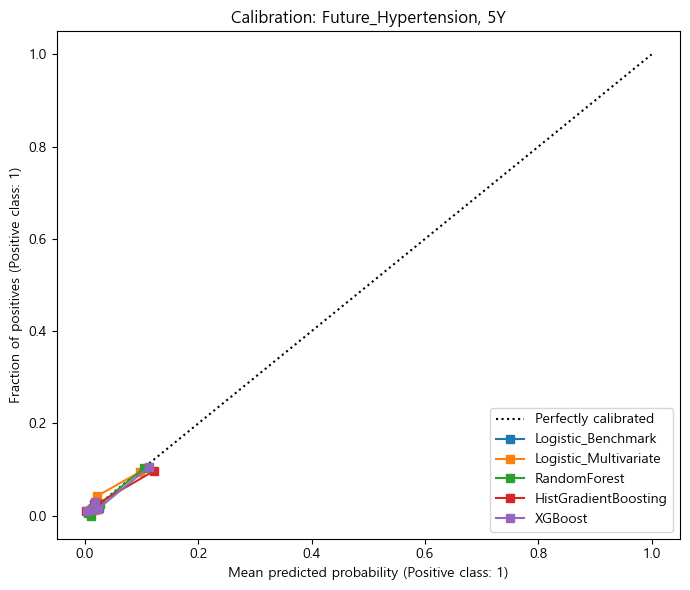

In [49]:
# Example: 5-year hypertension calibration
plot_calibration(
    fitted_store=fitted_store,
    followup_years=5,
    target_col='Future_Hypertension'
)


## 18. Stage 5: SHAP Interpretation

SHAP is used to inspect **which underwriting history features drive predictions** in the machine-learning models.

Typical questions:

- Does repeated respiratory utilization matter more than a simple history flag?
- Does recent respiratory disease matter more than remote history?
- Are cardiovascular or metabolic histories dominating the prediction?
- Does the ML model discover meaningful nonlinear combinations?

This step requires the optional `shap` package.


In [50]:
def shap_explain(fitted_store, followup_years, target_col, model_name='RandomForest'):
    """Step 5: SHAP explanation for a fitted tree model."""
    try:
        import shap
    except ImportError as e:
        raise ImportError('Install shap first: pip install shap') from e

    obj = fitted_store[(followup_years, target_col)][model_name]
    model = obj['model']
    X_test = obj['X_test']

    # Keep the explanation reasonably sized for notebook use.
    X_explain = X_test.sample(min(1000, len(X_test)), random_state=42)
    explainer = shap.Explainer(model, X_explain)
    shap_values = explainer(X_explain)

    # Some binary classifiers return (sample, feature, class).
    if len(shap_values.shape) == 3:
        shap.plots.beeswarm(shap_values[:, :, 1], max_display=15)
    else:
        shap.plots.beeswarm(shap_values, max_display=15)

    return shap_values

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.
 96%|=================== | 1922/2000 [00:16<00:00]       

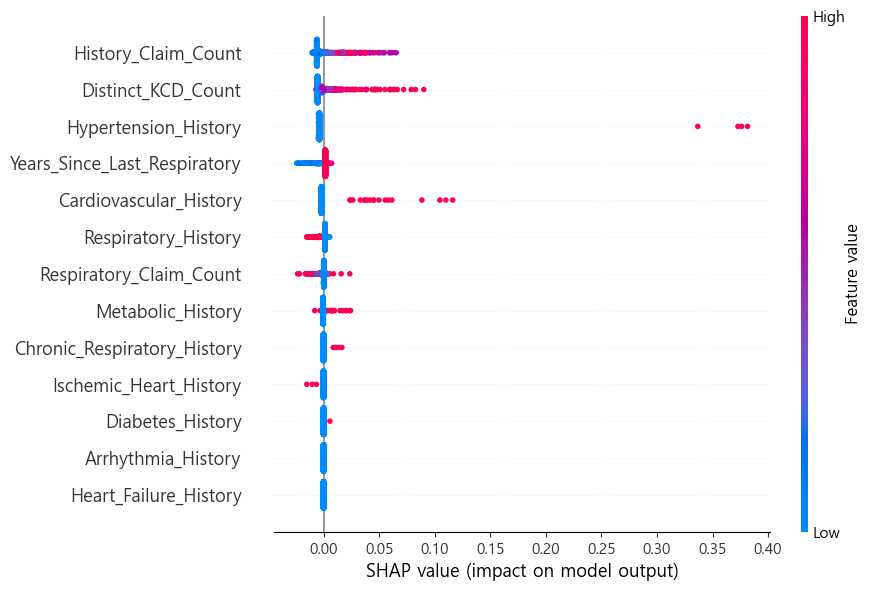

In [51]:
# Example: explain 5-year hypertension predictions from Random Forest.
# Uncomment after confirming SHAP is installed.

shap_values = shap_explain(
    fitted_store=fitted_store,
    followup_years=5,
    target_col='Future_Hypertension',
    model_name='RandomForest'
)


## 19. Stage 6: Out-of-Time Validation

A random Train/Test split measures performance within a similar calendar period.

For a stronger real-world test, Out-of-Time validation trains on an **earlier index cohort** and evaluates the model on a **later index cohort**.

Example for a 5-year outcome:

- Train index date: `2015-05-04`
- Train outcome period: approximately `2015-05-04 ~ 2020-05-03`
- Test index date: `2020-05-04`
- Test outcome period: approximately `2020-05-04 ~ 2025-05-03`

The actual feasibility depends on how far the raw exposure and claims data extend. If the raw data do not cover both windows, choose dates supported by the dataset.


In [52]:
def oot_validate(
    cohort_obj,
    train_index_date,
    test_index_date,
    followup_years,
    target_col,
    model_name='HistGradientBoosting',
):
    """Step 6: out-of-time validation using an earlier cohort for training."""

    fb = FeatureBuilder(history_years=cohort_obj.history_years)
    features = fb.feature_columns()

    train_data = build_model_data(
        cohort_obj, train_index_date, followup_years, feature_builder=fb
    )
    test_data = build_model_data(
        cohort_obj, test_index_date, followup_years, feature_builder=fb
    )

    y_train = train_data[target_col].astype(int)
    y_test = test_data[target_col].astype(int)

    if y_train.nunique() < 2 or y_test.nunique() < 2:
        raise ValueError('Train or OOT test target contains only one class.')

    model = make_models()[model_name]
    model.fit(train_data[features], y_train)
    pred = model.predict_proba(test_data[features])[:, 1]

    result = pd.DataFrame([{
        'Train_Index_Date': pd.Timestamp(train_index_date).date(),
        'Test_Index_Date': pd.Timestamp(test_index_date).date(),
        'Followup_Years': followup_years,
        'Target_Disease': target_col.replace('Future_', ''),
        'Model': model_name,
        'Train_Count': len(train_data),
        'Test_Count': len(test_data),
        'Test_Event_Count': int(y_test.sum()),
        'Test_Event_Rate': float(y_test.mean()),
        'ROC_AUC': roc_auc_score(y_test, pred),
        'PR_AUC': average_precision_score(y_test, pred),
        'Brier_Score': brier_score_loss(y_test, pred),
    }])

    return result, model, train_data, test_data, pred

In [53]:
# Example Out-of-Time validation.
# Adjust dates if the raw data do not cover these periods.

oot_result, oot_model, train_oot, test_oot, oot_pred = oot_validate(
    cohort_obj=cohort,
    train_index_date='2015-05-04',
    test_index_date='2020-05-04',
    followup_years=5,
    target_col='Future_Hypertension',
    model_name='HistGradientBoosting'
)
display(oot_result)



History period : 2010-05-04 ~ 2015-05-03
Follow-up period : 2015-05-04 ~ 2020-05-03
Follow-up years : 5
Eligible insured : 10,273

History period : 2015-05-04 ~ 2020-05-03
Follow-up period : 2020-05-04 ~ 2025-05-03
Follow-up years : 5
Eligible insured : 13,310


,Train_Index_Date,Test_Index_Date,Followup_Years,Target_Disease,Model,Train_Count,Test_Count,Test_Event_Count,Test_Event_Rate,ROC_AUC,PR_AUC,Brier_Score
0,2015-05-04,2020-05-04,5,Hypertension,HistGradientBoosting,10273,13310,311,0.023366,0.724873,0.119474,0.02158


## 20. Recommended Next Extension: Age and Sex

Age and sex were **not automatically added** to the extended feature set because the current notebook does not establish a reliable insured-level source for both variables.

When they are available from the exposure or policy population data, a particularly useful model sequence is:

1. Respiratory history only
2. Age + Sex only
3. Age + Sex + Respiratory history
4. Age + Sex + all historical medical features
5. Machine-learning model using all available underwriting features

The comparison between models 2 and 3 directly tests whether respiratory history provides **incremental underwriting information after controlling for basic demographic risk**.


## 21. Export Extended Model Comparison

Save the extended model comparison table for reporting or further review.


In [54]:
comparison_v2.to_excel(
    'Underwriting_Model_Comparison_v2.xlsx',
    index=False
)
